In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('placement_clean.csv')
print(df.shape)
df.head()

(215, 14)


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1
1,2,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1
2,3,1,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1
3,4,1,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0
4,5,1,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1


In [2]:
print("Total Students:", len(df))
print("Placed:", df['status'].sum())
print("Not Placed:", (df['status'] == 0).sum())
print("\nPlacement Rate:", round(df['status'].mean() * 100, 2), "%")

Total Students: 215
Placed: 148
Not Placed: 67

Placement Rate: 68.84 %


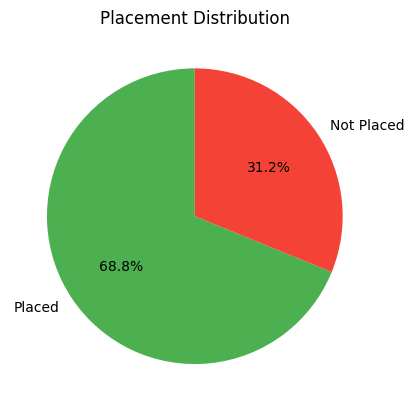

In [3]:
labels = ['Placed', 'Not Placed']
sizes = [df['status'].sum(), (df['status'] == 0).sum()]

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
ax.set_title('Placement Distribution')
plt.savefig('assets/placement_distribution.png', bbox_inches='tight')
plt.show()

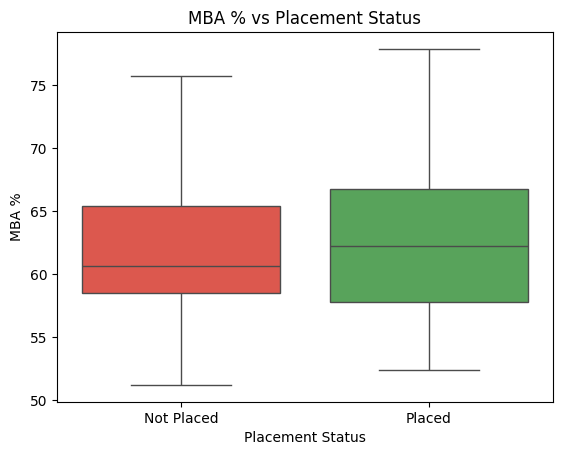

In [4]:
fig, ax = plt.subplots()
sns.boxplot(x='status', y='mba_p', data=df, palette=['#F44336', '#4CAF50'], ax=ax)
ax.set_xticklabels(['Not Placed', 'Placed'])
ax.set_title('MBA % vs Placement Status')
ax.set_xlabel('Placement Status')
ax.set_ylabel('MBA %')
plt.savefig('assets/mba_vs_placement.png', bbox_inches='tight')
plt.show()

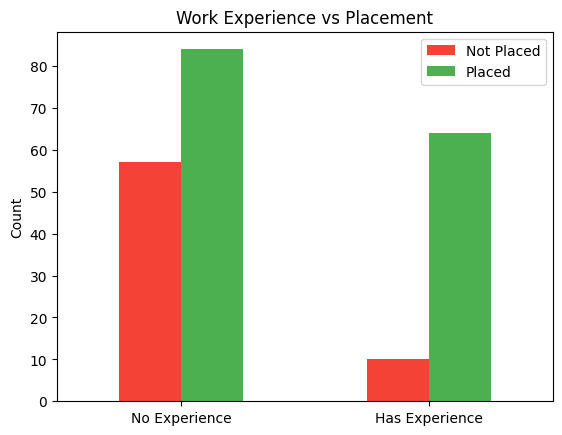

In [5]:
fig, ax = plt.subplots()
workex_data = df.groupby(['workex', 'status']).size().unstack()
workex_data.index = ['No Experience', 'Has Experience']
workex_data.columns = ['Not Placed', 'Placed']
workex_data.plot(kind='bar', color=['#F44336', '#4CAF50'], ax=ax, rot=0)
ax.set_title('Work Experience vs Placement')
ax.set_ylabel('Count')
plt.savefig('assets/workex_vs_placement.png', bbox_inches='tight')
plt.show()

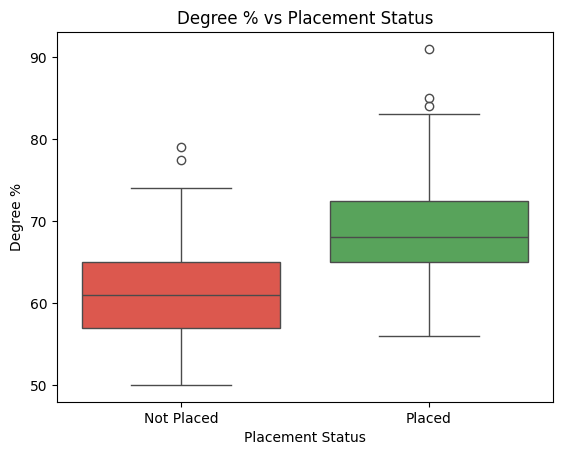

In [6]:
fig, ax = plt.subplots()
sns.boxplot(x='status', y='degree_p', data=df, palette=['#F44336', '#4CAF50'], ax=ax)
ax.set_xticklabels(['Not Placed', 'Placed'])
ax.set_title('Degree % vs Placement Status')
ax.set_xlabel('Placement Status')
ax.set_ylabel('Degree %')
plt.savefig('assets/degree_vs_placement.png', bbox_inches='tight')
plt.show()

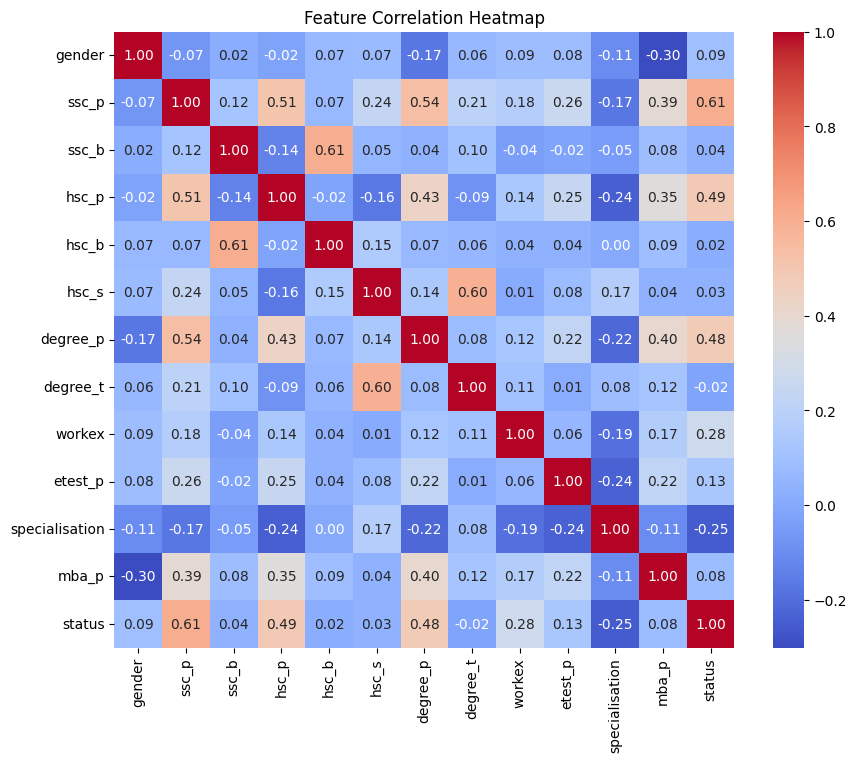

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.drop('sl_no', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.savefig('assets/correlation_heatmap.png', bbox_inches='tight')
plt.show()